<a href="https://colab.research.google.com/github/emily-speckman/SinkholeProject/blob/main/AZKarstDL_03_build_single_tile_stack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AZKarstDL_03_build_single_tile_stack

This notebook downloads a DEM for one 20 km × 20 km training tile from USGS 3DEP (The National Map), reprojects/returns it in NAD83(2011) / UTM Zone 12N at 10 m resolution, computes slope and multiscale TPI, and exports a 6-band float32 stack GeoTIFF for inspection in ArcGIS Pro. Once validated on one tile, we will scale this workflow to all selected training tiles.

**we will do the following:**

1.   Load your selected training tiles GeoPackage (the 6 tiles)
2.   Pick one tile_id to test AZ_UTM12N_20km_R201_C19 = North Kaibab Demonte Park and West
3.   Download DEM for that tile using exportImage (2000×2000 pixels at 10 m for 20 km)
4. Compute:
    - slope (degrees)
    - TPI at radii 5,15,30,50
5. Write a 6-band float32 GeoTIFF stack:
  B1 = DEM or elevation
  B2 = Slope
  B3 = TPI_5
  B4 = TPI_15
  B5 = TPI_30
  B6 = TPI_50
6. Plot each band (map + histogram) for quick sanity checks
7. Save outputs to Drive for ArcGIS Pro QA



1. Mount Drive + Installs

we need to connect to our google drive to access the files and to store our outputs somewhere

> **note:** you will have to allow this notebook access to your drive for it to work

we also need to install some libraries that will allow us to do this processing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install geopandas shapely pyproj rasterio numpy scipy matplotlib requests


Mounted at /content/drive


2. Load selected tiles + choose one tile

In [ ]:
import geopandas as gpd

SEL_GPKG = "/content/drive/MyDrive/DATA_COLAB/az_training_tiles_20km_utm12n.gpkg"
SEL_LAYER = "training_tiles"

tiles = gpd.read_file(SEL_GPKG, layer=SEL_LAYER)
tiles = tiles.set_index("tile_id")

print("Tiles loaded:", len(tiles))
tiles[["row","col","xmin","ymin","xmax","ymax"]]

tile_id = "AZ_UTM12N_20km_R201_C19" # North Kaibab Plateau around Demonte Park and west

row = tiles.loc[tile_id]
bbox = (float(row.xmin), float(row.ymin), float(row.xmax), float(row.ymax))
bbox


Tiles loaded: 6


(380000.0, 4020000.0, 400000.0, 4040000.0)

3. Download DEM via USGS 3DEPElevation ImageServer `exportImage`

    We’ll request TIFF output at 2000×2000 pixels (20,000 m / 10 m).

In [ ]:
import os, json
import requests

EXPORT_URL = "https://elevation.nationalmap.gov/arcgis/rest/services/3DEPElevation/ImageServer/exportImage"

OUT_DIR = "/content/drive/MyDrive/DATA_COLAB/tiles_dem"
os.makedirs(OUT_DIR, exist_ok=True)

dem_path = os.path.join(OUT_DIR, f"{tile_id}_dem_10m_utm12n.tif")

params = {
    "f": "json",
    "bbox": ",".join(map(str, bbox)),
    "bboxSR": 26912,
    "imageSR": 26912,
    "size": "2000,2000",
    "format": "tiff",
    "pixelType": "F32",
    "noData": "-9999",
    "interpolation": "RSP_BilinearInterpolation",
}

r = requests.get(EXPORT_URL, params=params, timeout=120)
r.raise_for_status()
info = r.json()

if "href" not in info:
    raise RuntimeError(f"Unexpected response (no href). Keys: {list(info.keys())}\n{json.dumps(info, indent=2)[:1200]}")

tiff_url = info["href"]
print("Download URL:", tiff_url)

# Download the TIFF
rt = requests.get(tiff_url, stream=True, timeout=300)
rt.raise_for_status()
with open(dem_path, "wb") as f:
    for chunk in rt.iter_content(chunk_size=1024*1024):
        if chunk:
            f.write(chunk)

dem_path


Download URL: https://elevation.nationalmap.gov/arcgis/rest/directories/elevation_output/3DEPElevation_ImageServer/_ags_8be1c6b4_e2a4_4098_85ec_5d93a98a2390.tif


'/content/drive/MyDrive/DATA_COLAB/tiles_dem/AZ_UTM12N_20km_R201_C19_dem_10m_utm12n.tif'

4. Read DEM + Enforce nodata as NaN

In [ ]:
import numpy as np
import rasterio

with rasterio.open(dem_path) as src:
    dem = src.read(1).astype("float32")
    dem_profile = src.profile
    transform = src.transform
    crs = src.crs
    nodata = src.nodata

print("CRS:", crs)
print("Nodata:", nodata)
print("Shape:", dem.shape)
print("Pixel size:", transform.a, transform.e)

dem = np.where(dem == nodata, np.nan, dem)


CRS: EPSG:26912
Nodata: -9999.0
Shape: (2000, 2000)
Pixel size: 10.0 -10.0


5. Compute slope (degrees)

We’ll use a standard finite-difference gradient. (Good enough for v1 QA; later we can swap to a more GIS-faithful algorithm if needed.)

In [ ]:
def slope_degrees(dem_nan: np.ndarray, cellsize: float = 10.0) -> np.ndarray:
    """Compute slope (degrees) from DEM using central differences. NaNs propagate."""
    z = dem_nan
    # fill NaNs temporarily to compute gradients, but mask output back to NaN
    valid = np.isfinite(z)
    z0 = np.where(valid, z, 0.0).astype("float32")

    dzdy, dzdx = np.gradient(z0, cellsize, cellsize)  # y, x
    slope = np.degrees(np.arctan(np.sqrt(dzdx**2 + dzdy**2))).astype("float32")
    slope[~valid] = np.nan
    return slope

slope = slope_degrees(dem, 10.0)
np.nanmin(slope), np.nanmax(slope)


(np.float32(0.0), np.float32(78.823204))

6. Compute TPI with Circular Kernals (NaN aware)

This does: TPI = DEM - mean(DEM within disk radius) with proper handling of NaNs via convolving the valid mask.

In [ ]:
from scipy.signal import convolve2d

def disk_kernel(radius_cells: int) -> np.ndarray:
    r = radius_cells
    y, x = np.ogrid[-r:r+1, -r:r+1]
    mask = (x*x + y*y) <= (r*r)
    k = mask.astype("float32")
    return k

def tpi_nanaware(dem_nan: np.ndarray, radius_cells: int) -> np.ndarray:
    z = dem_nan.astype("float32")
    valid = np.isfinite(z).astype("float32")

    k = disk_kernel(radius_cells)
    z_filled = np.where(np.isfinite(z), z, 0.0).astype("float32")

    sum_z = convolve2d(z_filled, k, mode="same", boundary="symm")
    count = convolve2d(valid, k, mode="same", boundary="symm")

    mean = np.where(count > 0, sum_z / count, np.nan).astype("float32")
    tpi = (z - mean).astype("float32")
    tpi[~np.isfinite(z)] = np.nan
    return tpi

tpi_5  = tpi_nanaware(dem, 5)
tpi_15 = tpi_nanaware(dem, 15)
tpi_30 = tpi_nanaware(dem, 30)
tpi_50 = tpi_nanaware(dem, 50)

(np.nanmin(tpi_5), np.nanmax(tpi_5), np.nanmin(tpi_50), np.nanmax(tpi_50))


(np.float32(-45.836914),
 np.float32(44.961914),
 np.float32(-237.328),
 np.float32(163.05469))

7. Write the 6-band stack GeoTIFF

In [ ]:
import os
import rasterio

STACK_DIR = "/content/drive/MyDrive/DATA_COLAB/tiles_stack"
os.makedirs(STACK_DIR, exist_ok=True)

stack_path = os.path.join(STACK_DIR, f"{tile_id}_stack_6band_10m_utm12n.tif")

bands = [dem, slope, tpi_5, tpi_15, tpi_30, tpi_50]
band_names = ["DEM", "SLOPE_DEG", "TPI_R5", "TPI_R15", "TPI_R30", "TPI_R50"]

profile = dem_profile.copy()
profile.update({
    "count": 6,
    "dtype": "float32",
    "nodata": -9999.0,
    "compress": "deflate",
    "predictor": 3
})

with rasterio.open(stack_path, "w", **profile) as dst:
    for i, (arr, name) in enumerate(zip(bands, band_names), start=1):
        out = np.where(np.isfinite(arr), arr, profile["nodata"]).astype("float32")
        dst.write(out, i)
        dst.set_band_description(i, name)

stack_path


'/content/drive/MyDrive/DATA_COLAB/tiles_stack/AZ_UTM12N_20km_R201_C19_stack_6band_10m_utm12n.tif'

8. Plot each band + histogram (QA)

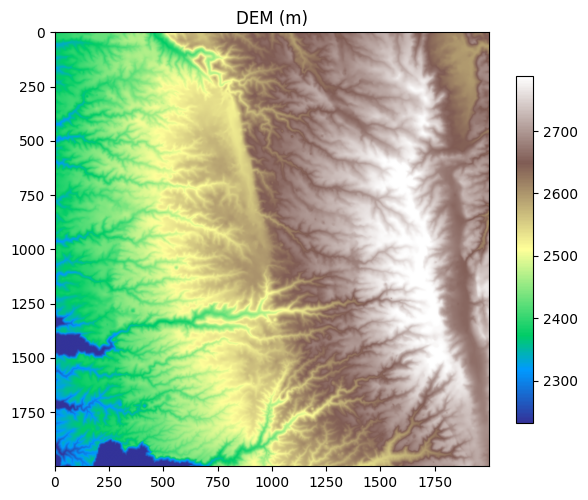

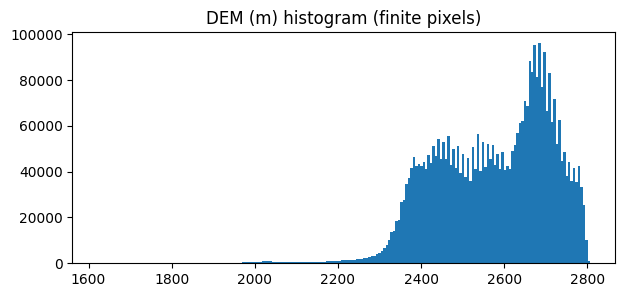

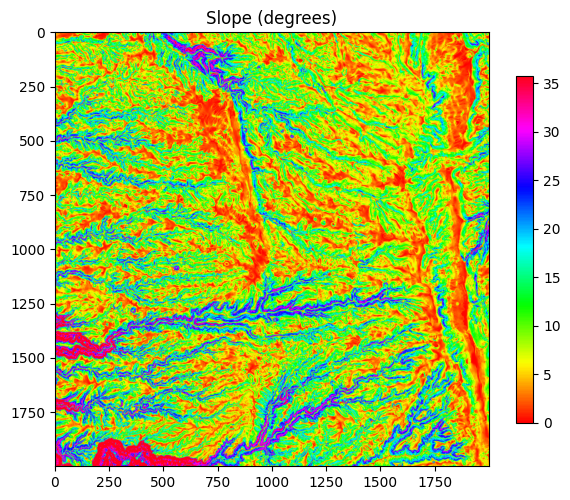

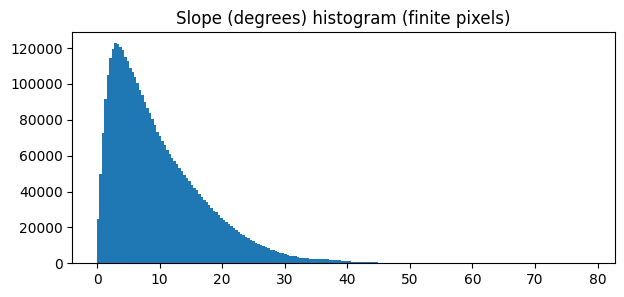

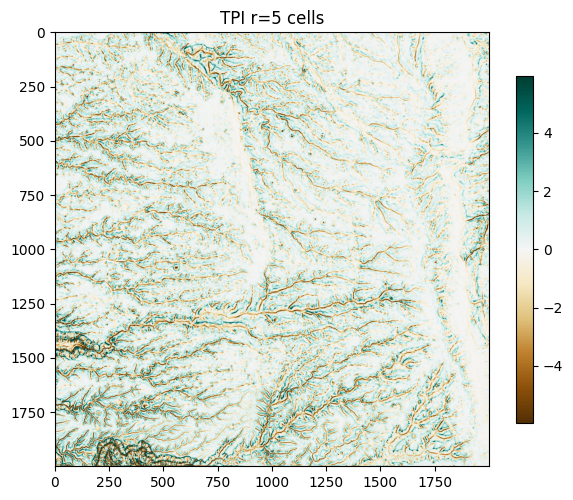

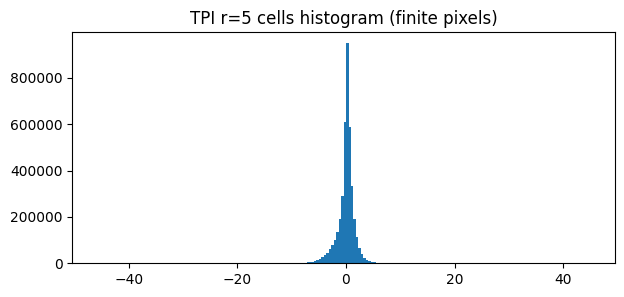

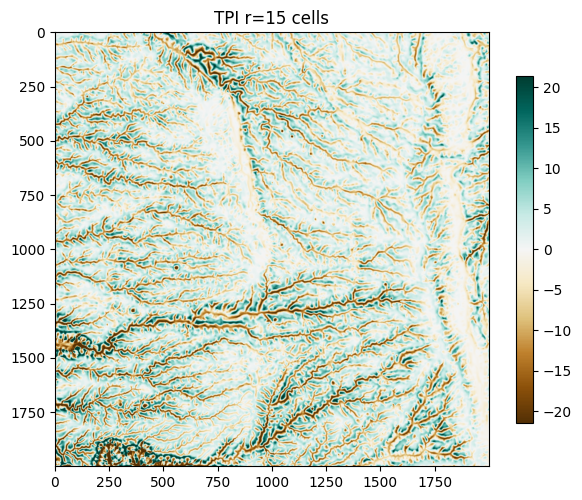

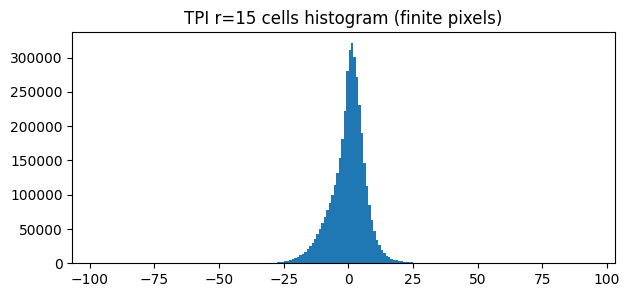

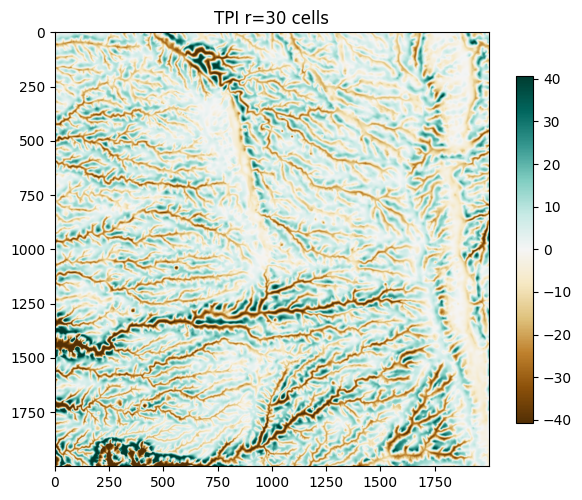

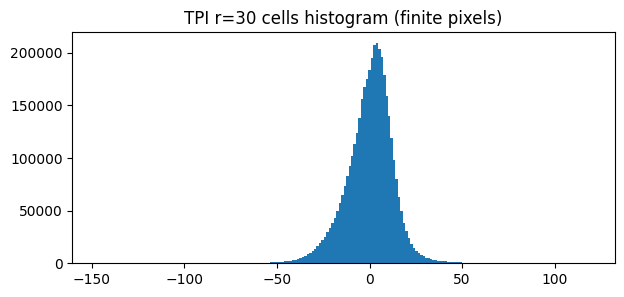

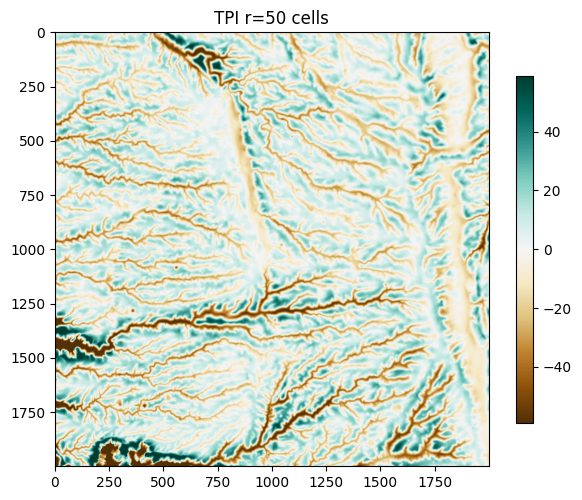

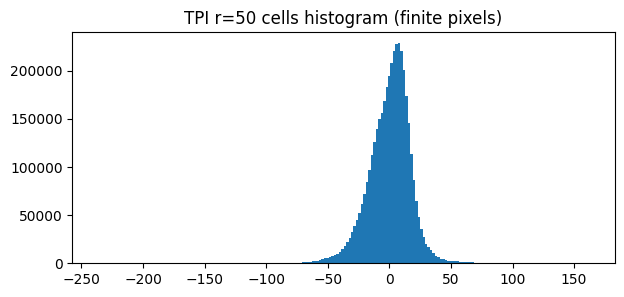

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_band(arr, title, cmap="viridis", vmin=None, vmax=None, bins=200):
    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.75)
    plt.show()

    vals = arr[np.isfinite(arr)]
    fig, ax = plt.subplots(figsize=(7,3))
    ax.hist(vals, bins=bins)
    ax.set_title(f"{title} histogram (finite pixels)")
    plt.show()

# DEM — terrain colormap makes physical sense
plot_band(
    dem,
    "DEM (m)",
    cmap="terrain",
    vmin=np.nanpercentile(dem, 1),
    vmax=np.nanpercentile(dem, 99)
)

# Slope — hsv as requested
plot_band(
    slope,
    "Slope (degrees)",
    cmap="hsv",
    vmin=0,
    vmax=np.nanpercentile(slope, 99)
)

# TPI — diverging BrBG centered around 0
for arr, name in [
    (tpi_5,  "TPI r=5 cells"),
    (tpi_15, "TPI r=15 cells"),
    (tpi_30, "TPI r=30 cells"),
    (tpi_50, "TPI r=50 cells"),
]:
    vmax = np.nanpercentile(np.abs(arr), 99)
    plot_band(
        arr,
        name,
        cmap="BrBG",
        vmin=-vmax,
        vmax=vmax
    )


# ArcGIS Pro QA checklist (for this one tile)

1. Open the exported `*_stack_6band_10m_utm12n.tif` and confirm:
   - CRS = NAD83(2011) / UTM Zone 12N
   - Pixel size = 10 m
   - Extent matches the 20 km tile boundaries exactly

2. Inspect each band visually:
   - DEM looks reasonable (no huge steps/voids)
   - Slope highlights ridges/canyons
   - TPI_5 shows local pits/knobs
   - TPI_50 shows broader valleys/ridges

3. If everything looks correct, we will:
   - Run this same process for all 6 training tiles
   - Then move on to rasterizing sinkhole polygons into `label.tif` aligned to the same tile grid


**NOTES: Two important notes**

This approach uses the National Map 3DEPElevation ImageServer rather than downloading pre-staged 1×1° 1/3 arc-second tiles and mosaicking. It’s still “National Map 3DEP,” but it’s much easier to automate per tile.

Your tile bbox is already snapped to 20,000 m boundaries, and the output is 2000×2000 pixels, so it SHOULD BE be inherently aligned to a 10 m grid (origin-aligned by construction).